# Predictive Modeling with heterogeneous data

## Overview of scikit-learn library

As introduced before, packages are usually object oriented. Scikit-learn is fully developed around objects which have all the same structures:

* constructor : first definition of models (where you define your parameters)
* fit (method): where you train your model ( iesolve the optimization program) 
* predict (method): use the model to predict a value (for unsupervised model that mean it adds a column with class tag).

Let's have a look at the documentation for the linear regression for instance:

http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter('ignore', DeprecationWarning)

## Load the dataset with Pandas

We can load the CSV file as a pandas DataFrame in one line:

In [10]:
data = pd.read_csv('data_train.csv')

In [11]:
data.head(5)

,PolNum,CalYear,sex,type,catgry,occup,age,group,bonus,poldur,value,adind,numad,numtppd,numtpbi,incad,inctppd,inctpbi,Density,Y
0,50117481,1,Male,C,Large,Employed,25,18,90,3,15080,0,0,1,0,0.000000,0.0,0.0,72.012883,0.0
1,77067429,1,Male,E,Large,Employed,20,11,30,2,22370,1,1,1,0,862.055824,0.0,0.0,39.550411,0.0
2,15821618,1,Female,E,Large,Unemployed,42,11,150,0,39650,0,0,2,0,0.000000,0.0,0.0,169.529148,0.0
3,43517309,1,Female,C,Medium,Housewife,21,5,0,0,12600,1,0,1,0,0.000000,0.0,0.0,58.894688,0.0
4,93881884,1,Female,D,Large,Employed,33,12,30,10,9065,0,0,2,0,0.000000,0.0,0.0,109.631885,0.0


In [12]:
data.shape

(72593, 20)

The DataFrame has 72593 rows and 20 columns.

In [13]:
list(data.columns)

['PolNum',
 'CalYear',
 'sex',
 'type',
 'catgry',
 'occup',
 'age',
 'group',
 'bonus',
 'poldur',
 'value',
 'adind',
 'numad',
 'numtppd',
 'numtpbi',
 'incad',
 'inctppd',
 'inctpbi',
 'Density',
 'Y']

As it is, the dataframe cannot be directly fed to a scikit-learn model because:


- the target variable (Y) is mixed with the input data

- some attribute such as unique ids (PolNum) have no predictive values for the task

- the values are heterogeneous (string labels for categories, integers and floating point numbers)

Thus, we need to preprocess the data.

## Preprocessing the data

**Step 1** Add a column with whether a policyholder has had an accident.

In [14]:
def has_encountered_accident(row):
    if row['numtppd'] + row['numtpbi'] > 0:
        return 1
    
    else: return 0

In [15]:
data['has_acc'] = data.apply (lambda row: has_encountered_accident (row),axis=1)

Let us have a look at the newly created `has_acc` column:

In [16]:
Y_column = data['has_acc']
Y_column.dtype

dtype('int64')

NB: `data['has_acc']` is an instance of the pandas `Series` class with an integer dtype and `data` is an instance of the pandas `DataFrame` class. `Series` can be seen as homogeneous, 1D columns, whereas `DataFrame` instances are heterogenous collections of columns with the same length.

In [17]:
print(type(Y_column), type(data))

<class 'pandas.core.series.Series'> <class 'pandas.core.frame.DataFrame'>


Let's have a quick look at this variable.

In [18]:
pd.value_counts(data['has_acc'])

C:\Users\u011513\AppData\Local\Temp\ipykernel_21840\3006217362.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(data['has_acc'])


has_acc
0    59891
1    12702
Name: count, dtype: int64

In [19]:
np.mean(data['has_acc'] == 0)

np.float64(0.825024451393385)

From this the subset of the full policyholder list, about 80% never encountered any accident during their warranty period. So if we are to build a predictive model from this data, a baseline model to compare the performance would be to always predict "no accident". Such a constant model would reach around 82.5% predictive accuracy (which is higher than predicting at random).

**Step 2** Converting to numpy arrays to be understandable by scikit-learn

**`sklearn` estimators all work with homegeneous numerical feature descriptors passed as a numpy array. Therefore passing the raw DataFrame will not work out of the box. You need to convert our DataFrame using the `values`attribute.** 

First, we start with the `Series Y_column`. pandas `Series` instances can be converted to regular 1D numpy arrays by using the `values` attribute:

In [20]:
target = Y_column.values
type(target) # check

numpy.ndarray

In [21]:
target.dtype

dtype('int64')

Then we should convert the features. The method is exactly the same. We preprocess only the features we want to have in the model. To simplify things, let's start with only the numerical features: this way, we don't have to deal with the heterogeneity of the features. 

## Training a predictive model on numerical features

### Preprocessing the features of the model

Let us start simple and build a first model that only uses readily available numerical features as inputs, namely `data.CalYear`, `data.age`, `data.group`, `data.bonus`, `data.poldur`, `data.value` and `data.Density`.

In [22]:
# extract numerical features
numerical_features = data[['CalYear', 'age', 'group', 'bonus','poldur','value','Density']]
numerical_features.head(5)

,CalYear,age,group,bonus,poldur,value,Density
0,1,25,18,90,3,15080,72.012883
1,1,20,11,30,2,22370,39.550411
2,1,42,11,150,0,39650,169.529148
3,1,21,5,0,0,12600,58.894688
4,1,33,12,30,10,9065,109.631885


We can ensure no missing data can be found within these variables

In [23]:
numerical_features.count()

CalYear    72593
age        72593
group      72593
bonus      72593
poldur     72593
value      72593
Density    72593
dtype: int64

We can now convert our Data Frame into an homogeneous numpy array of floating point values:

In [24]:
# convert to numpy array
features_array = numerical_features.values
features_array # check

array([[1.00000000e+00, 2.50000000e+01, 1.80000000e+01, ...,
        3.00000000e+00, 1.50800000e+04, 7.20128830e+01],
       [1.00000000e+00, 2.00000000e+01, 1.10000000e+01, ...,
        2.00000000e+00, 2.23700000e+04, 3.95504106e+01],
       [1.00000000e+00, 4.20000000e+01, 1.10000000e+01, ...,
        0.00000000e+00, 3.96500000e+04, 1.69529148e+02],
       ...,
       [2.00000000e+00, 4.70000000e+01, 1.00000000e+01, ...,
        9.00000000e+00, 2.19800000e+04, 4.56698229e+01],
       [2.00000000e+00, 4.60000000e+01, 7.00000000e+00, ...,
        1.00000000e+00, 2.89250000e+04, 5.49318122e+01],
       [2.00000000e+00, 6.70000000e+01, 1.70000000e+01, ...,
        9.00000000e+00, 1.45250000e+04, 7.32524990e+01]], shape=(72593, 7))

In [25]:
features_array.dtype

dtype('float64')

We are now nearly ready to run our first modelization. We just need to separate the dataset into two sets: a training set and a test set. Indeed, you should never evaluate a model on the data it was trained on. Otherwise the model may just learn trends of the dataset and not generalize well. 

**Step 3** Split the dataset

Let's take the 80% of the data for training a first model and keep 20% for computing is generalization score. `scikit-learn` has a nice function to do this automatically.

In [26]:
from sklearn.model_selection import train_test_split

features_train, features_test, target_train, target_test = train_test_split(
    features_array, 
    target, 
    test_size=0.20, 
    random_state=0 # set a seed for the purpose of this tutorial
)

In [27]:
features_train.shape # 7 features and 80% of the dataset

(58074, 7)

In [28]:
features_test.shape # 7 features and 20 % of the dataset

(14519, 7)

In [29]:
target_train.shape # the Y column and 80 % of the dataset

(58074,)

In [30]:
target_test.shape # the Y column and 20 % of the dataset

(14519,)

The preprocessing is finished! Now we can start the modelization. 

### Modeling

Let's start with a simple model from sklearn, namely `LogisticRegression`. If you remember from the first [hands-on](python-part-1.C-hands-on.ipynb), there are three main steps in every modelization with scikit-learn: 
1. Constructor : first definition of models (where you define your parameters)
2. Fit (method): where you train your model ( iesolve the optimization program) 
3. Predict (method): use the model to predict a value (for unsupervised model that mean it adds a column with class tag).


In [31]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(C=1, solver='lbfgs', random_state=42, max_iter=1000) # constructor
logreg.fit(features_train, target_train) # fit

LogisticRegression(C=1, max_iter=1000, random_state=42)

If you are not sure of how to read the documentation of a function, you can have a look at the documentation of this training material in "./documentation/Tutorial_full_documentation.docx". Let's have a look at the different options for a logistic regression with Scikit-learn.

- `C` parameter indicates the weakness of the regularization (a smaller value >0 stands for a stronger regularzation)


- Use `class_weight` to specify an optionnal weight column to be applied during the regression


- `fit_intercept` if set to `TRUE` allows to add a bias to the decision function


- Use `penallty` parameter to chose between the regular `l2` or `l1` regularization norm


- `solver` lets you indicate which solving method should be used between `{‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’}`. Note that for small datasets, `liblinear` is a good choice, whereas `sag` and `saga` are faster for large ones.


- `n_jobs` parameter helps you to speed up your calculations by parallelizing the fitting process according to the number of cores designated by the parameter.

In [32]:
target_predicted = logreg.predict(features_test) # predict

## Model evaluation and interpretation

### A first metric: the accuracy score

Now that we have a model, let's evaluate it. A classic metric is the accuracy score.

In [33]:
logreg.score(features_test, target_test)

0.8309800950478683

In [34]:
# other method to compute the accuracy score
from sklearn.metrics import accuracy_score
accuracy_score(target_test, target_predicted)

0.8309800950478683

This first model has around 83.1% accuracy: this is slightly better than our baseline that always predicts no accident (~ 82.5%).

### Interpreting linear model weights

Often a good accuracy is not enough to convince someone to use a model and we may want to also understand what the model uses to make its predictions: we want to interprete its inner workings. 

The `coef_` attribute of a fitted linear model such as `LogisticRegression` holds the weights of each features.

In [35]:
feature_names = numerical_features.columns
feature_names

Index(['CalYear', 'age', 'group', 'bonus', 'poldur', 'value', 'Density'], dtype='object')

In [36]:
logreg.coef_

array([[ 1.18761252e-01, -3.83892793e-02,  6.90570048e-02,
         1.01346041e-02, -1.66316688e-02, -2.70271776e-07,
         3.69125689e-03]])

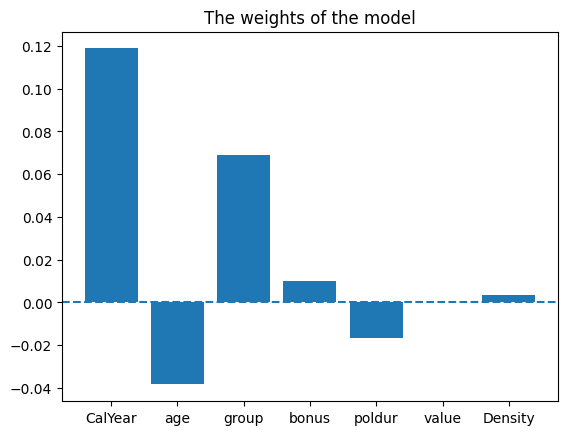

In [37]:
x = np.arange(len(feature_names))
plt.bar(x, logreg.coef_.ravel())
_ = plt.xticks(x, feature_names, rotation=0)
_ = plt.title("The weights of the model")
_ = plt.axhline(0, linestyle="--")

In the model, accidentatlity is positively linked with the group and bonus variables (the higher the bonus, the higher the likelyhood the model will predict accidents for a policyhoder) while older customers are predicted to be less subject to encounter accidents during their warranty period.

### Alternative evaluation metrics

The accuracy metrics aggregates all errors in one measures but it can be interresting to have a closer look at the errors. It is possible to see the details of the false positive and false negative errors by computing the confusion matrix:

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(target_test, target_predicted)
print(cm)

[[11876   151]
 [ 2303   189]]


The true labelings are displayed on rows and the predicted labels on columns:

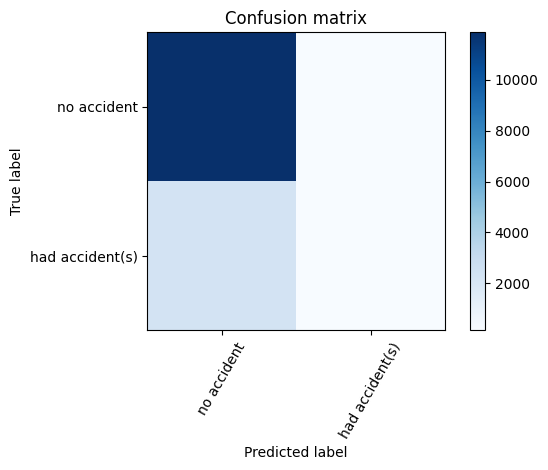

In [39]:
def plot_confusion(cm):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.binary)
    plt.title('Confusion matrix')
    plt.set_cmap('Blues')
    plt.colorbar()

    target_names = ['no accident','had accident(s)']

    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation=60)
    plt.yticks(tick_marks, target_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    # Convenience function to adjust plot parameters for a clear layout.
    plt.tight_layout()
    
plot_confusion(cm)

We can normalize the number of predictions by dividing by the total number of true "survived" and "not survived" to compute false and true positive rates for survival (in the second column of the confusion matrix).

In [40]:
print(cm.astype(np.float64) / cm.sum(axis=1))

[[0.98744492 0.0605939 ]
 [0.19148582 0.0758427 ]]


The accuracy score is actually not very informative because the target classes are not balanced in the dataset (~80% 20%). Scikit-learn provides alternative classification metrics to evaluate models performance on imbalanced data such as precision, recall and f1 score:

In [41]:
from sklearn.metrics import classification_report

print(classification_report(
    target_test, 
    target_predicted,
    target_names=['no accident', 'had accident(s)'])
)

                 precision    recall  f1-score   support

    no accident       0.84      0.99      0.91     12027
had accident(s)       0.56      0.08      0.13      2492

       accuracy                           0.83     14519
      macro avg       0.70      0.53      0.52     14519
   weighted avg       0.79      0.83      0.77     14519



A logistic regression is a probabilistic model: it predicts a binary outcome (survived or not) based on the estimated posterior probability of the outcome given the input features. You can access this probability with the `predict_proba` method:

In [42]:
target_predicted_proba = logreg.predict_proba(features_test)
target_predicted_proba[:5]

array([[0.49986786, 0.50013214],
       [0.83236288, 0.16763712],
       [0.90274682, 0.09725318],
       [0.92030973, 0.07969027],
       [0.9816224 , 0.0183776 ]])

By default the decision threshold is 0.5 but if you vary the decision threshold from 0 to 1, you can generate a family of binary classifier models that address all the possible trade-offs between false positive and false negative prediction errors.

We can summarize the performance of the binary classifier for all the possible thresholds by plotting the ROC curve and quantifying the Area under the ROC curve:

In [43]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

def plot_roc_curve(target_test, target_predicted_proba):
    fpr, tpr, thresholds = roc_curve(target_test, target_predicted_proba[:, 1])
    
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate or (1 - Specifity)')
    plt.ylabel('True Positive Rate or (Sensitivity)')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")

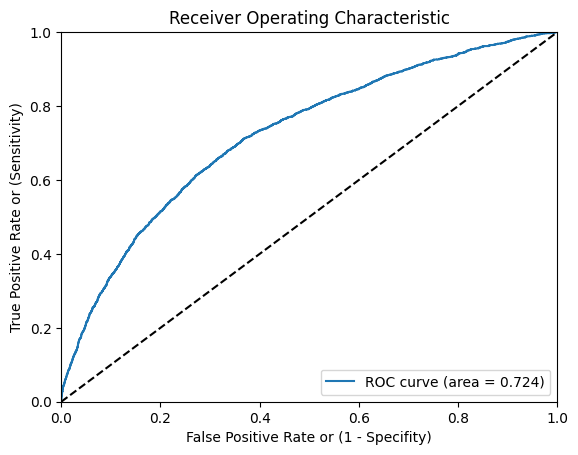

In [44]:
plot_roc_curve(target_test, target_predicted_proba)

Here the area under ROC curve is 0.716 which differs from the accuracy of the model (0.803). Indeed the ROC-AUC score of a random model is expected to 0.5 on average while the accuracy score of a random model depends on the class imbalance of the data. ROC-AUC can be seen as a way to callibrate the predictive accuracy of a model against class imbalance.

### Cross-validation

We previously decided to randomly split the data to evaluate the model on 20% of held-out data. However the randomness of the split might have a significant impact in the estimated accuracy (especially when the orignal dataset is not large). See how the accuracy of the model changes depending on seed (`random_state`) you choose when training it.

In [45]:
features_train, features_test, target_train, target_test = train_test_split(
    features_array, target, test_size=0.20, random_state=0)

logreg.fit(features_train, target_train).score(features_test, target_test)

0.8309800950478683

In [46]:
features_train, features_test, target_train, target_test = train_test_split(
    features_array, target, test_size=0.20, random_state=13)

logreg.fit(features_train, target_train).score(features_test, target_test)

0.8294648391762518

In [47]:
features_train, features_test, target_train, target_test = train_test_split(
    features_array, target, test_size=0.20, random_state=16)

logreg.fit(features_train, target_train).score(features_test, target_test)

0.8209243060816861

So instead of using a single train / test split, we can use a group of them and compute the min, max and mean scores as an estimation of the real test score while not underestimating the variability. This is called **cross-validation**.

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(logreg, features_array, target, cv=5)
scores

array([0.82829396, 0.82863834, 0.83063572, 0.82890205, 0.82786885])

In [49]:
scores.min(), scores.mean(), scores.max()

(np.float64(0.8278688524590164),
 np.float64(0.8288677838818801),
 np.float64(0.83063571871341))

`cross_val_score` reports accuracy by default but it can also be used to report other performance metrics such as ROC-AUC or f1-score:

In [50]:
scores = cross_val_score(
    logreg, features_array, target, cv=5,
    scoring='roc_auc'
)
scores.min(), scores.mean(), scores.max()

(np.float64(0.7193169432673813),
 np.float64(0.7283063866067312),
 np.float64(0.7336332666559293))

## Exercise 1

1. Compute cross-validated scores for other classification metrics ('precision', 'recall', 'f1', 'accuracy'...).

2. Change the number of cross-validation folds between 3 and 10: what is the impact on the mean score? on the processing time?

Hints:

The list of classification metrics is available in the online documentation:

  http://scikit-learn.org/stable/modules/model_evaluation.html#common-cases-predefined-values
  
You can use the `%%time` cell magic on the first line of an IPython cell to measure the time of the execution of a cell. 



In [51]:
# Q1 cross-validated scores for other metrics
scores = cross_val_score(
    logreg, features_array, target, cv=5,
    scoring='accuracy'
)

scores.min(), scores.mean(), scores.max()


(np.float64(0.8278688524590164),
 np.float64(0.8288677838818801),
 np.float64(0.83063571871341))

In [53]:
# Q2 number of cross-validation folds
%time scores_cv3 = cross_val_score(logreg, features_array, target, cv=3)
%time scores_cv_10 = cross_val_score(logreg, features_array, target, cv=10)

CPU times: total: 7.58 s
Wall time: 8.6 s
CPU times: total: 39.6 s
Wall time: 43 s


In [54]:
print(scores_cv3.min(), scores_cv3.mean(), scores_cv3.max())
print(scores_cv_10.min(), scores_cv_10.mean(), scores_cv_10.max())

0.8285808744524341 0.829115756036335 0.8295726919580131
0.8264223722275795 0.8288953581703649 0.8315194930431189


## More feature engineering and richer models

Let's now try to build richer models by including more features as potential predictors for our model.

Categorical variables such as `data.sex`, `data.catgry`, `data.type` and `data.occup` can be converted as boolean indicators features also known as [dummy variables](https://en.wikipedia.org/wiki/Dummy_variable_(statistics)) or one-hot-encoded features:

In [55]:
pd.get_dummies(data.sex, prefix='sex').head(5)

,sex_Female,sex_Male
0,False,True
1,False,True
2,True,False
3,True,False
4,True,False


In [60]:
pd.get_dummies(data.type, prefix='type').head(5)

,type_A,type_B,type_C,type_D,type_E,type_F
0,False,False,True,False,False,False
1,False,False,False,False,True,False
2,False,False,False,False,True,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False


We can combine those new numerical features with the previous features using `pandas.concat` along `axis=1`:

In [61]:
rich_features = pd.concat(
    [
        data[['CalYear', 'age', 'group', 'bonus','poldur','value','Density']],
        pd.get_dummies(data.sex, prefix='sex'),
        pd.get_dummies(data.type, prefix='type'),
        pd.get_dummies(data.catgry, prefix='catgry'),
        pd.get_dummies(data.occup, prefix='occup')
    ], 
    axis=1
)
rich_features.head(5)

,CalYear,age,group,bonus,poldur,value,Density,sex_Female,sex_Male,type_A,...,type_E,type_F,catgry_Large,catgry_Medium,catgry_Small,occup_Employed,occup_Housewife,occup_Retired,occup_Self-employed,occup_Unemployed
0,1,25,18,90,3,15080,72.012883,False,True,False,...,False,False,True,False,False,True,False,False,False,False
1,1,20,11,30,2,22370,39.550411,False,True,False,...,True,False,True,False,False,True,False,False,False,False
2,1,42,11,150,0,39650,169.529148,True,False,False,...,True,False,True,False,False,False,False,False,False,True
3,1,21,5,0,0,12600,58.894688,True,False,False,...,False,False,False,True,False,False,True,False,False,False
4,1,33,12,30,10,9065,109.631885,True,False,False,...,False,False,True,False,False,True,False,False,False,False


By construction the new `sex_Male` feature is redundant with `sex_Female`. Let us drop it:

In [75]:
rich_features_no_male = rich_features.drop(['sex_Male'], axis=1)
rich_features_no_male.head(5)

,CalYear,age,group,bonus,poldur,value,Density,sex_Female,type_A,type_B,...,type_E,type_F,catgry_Large,catgry_Medium,catgry_Small,occup_Employed,occup_Housewife,occup_Retired,occup_Self-employed,occup_Unemployed
0,1,25,18,90,3,15080,72.012883,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1,1,20,11,30,2,22370,39.550411,False,False,False,...,True,False,True,False,False,True,False,False,False,False
2,1,42,11,150,0,39650,169.529148,True,False,False,...,True,False,True,False,False,False,False,False,False,True
3,1,21,5,0,0,12600,58.894688,True,False,False,...,False,False,False,True,False,False,True,False,False,False
4,1,33,12,30,10,9065,109.631885,True,False,False,...,False,False,True,False,False,True,False,False,False,False


We can finally cross-validate a logistic regression model on this new data :

In [76]:
%%time

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

logreg = LogisticRegression(C=1, solver="lbfgs", max_iter=1000)
scores = cross_val_score(logreg, rich_features_no_male, target, cv=5, scoring='accuracy')
print("Logistic Regression CV scores:")
print("min: {:.3f}, mean: {:.3f}, max: {:.3f}".format(
    scores.min(), scores.mean(), scores.max()))

c:\Users\u011513\OneDrive - SCOR\DAS  Team and DSandMLE Chapter\02_Training&Conferences&Events\AI Training & Acculturation\UniversityCourses\DSA\2025\TD\.env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\u011513\OneDrive - SCOR\DAS  Team and DSandMLE Chapter\02_Training&Conferences&Events\AI Training & Acculturation\UniversityCourses\DSA\2025\TD\.env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (

Logistic Regression CV scores:
min: 0.829, mean: 0.831, max: 0.832
CPU times: total: 1min 14s
Wall time: 36.1 s


c:\Users\u011513\OneDrive - SCOR\DAS  Team and DSandMLE Chapter\02_Training&Conferences&Events\AI Training & Acculturation\UniversityCourses\DSA\2025\TD\.env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Exercise 2

- change the value of the parameter `C`. Does it have an impact on the score?

- fit a new instance of the logistic regression model on the full dataset.

- plot the weights for the features of this newly fitted logistic regression model.



In [78]:
#we get types of each variable to produce dummies if necessary as previously, we drop PolNum 
rich_features = pd.concat([data.get(['CalYear', 'age', 'group', 'bonus','poldur','value','Density']),
                           pd.get_dummies(data.sex, prefix='sex'),
                           pd.get_dummies(data.type, prefix='type'),
                           pd.get_dummies(data.catgry, prefix='catgry'),
                           pd.get_dummies(data.occup, prefix='occup')],
                          axis=1)
full_target=data['has_acc']

In [80]:
full_features = rich_features.drop(['sex_Male'], axis=1)

print('features shape', full_features.shape) 
print('label shape', full_target.shape)

features shape (72593, 22)
label shape (72593,)


**Be careful** 

$C$ in scikit learn is a factor of the likelihood functions (whereas in a traditional Ridge/Lasso optimisation where it is usual to find it associated to the weigths norm). Thus $C$ has to be in $]0,+\infty[$

The program optimized is :

$$ ||w||_{1~or~2} + C\sum_{i}^nlog(exp(-y_i(X_i^Tw+c))+1)$$

#### Remark to preprocess your data

You can build your own pipeline with preprocessing class of scikit-learn http://scikit-learn.org/stable/modules/preprocessing.html 

### Training Non-linear models: ensembles of randomized trees

We can train now with some non linear models. Let us consider the example of a decision tree.

In [81]:
from sklearn.tree import DecisionTreeClassifier

In [82]:
%%time

tree_classifier = DecisionTreeClassifier()

scores = cross_val_score(tree_classifier, rich_features_no_male, target, cv=5, n_jobs=4,
                         scoring='accuracy')
print("DecisionTreeClassifier CV scores:")
print("min: {:.3f}, mean: {:.3f}, max: {:.3f}".format(
    scores.min(), scores.mean(), scores.max()))

DecisionTreeClassifier CV scores:
min: 0.726, mean: 0.734, max: 0.738
CPU times: total: 172 ms
Wall time: 9.31 s


In [83]:
tree_classifier.fit(rich_features_no_male, target)

DecisionTreeClassifier()

`sklearn` also implements non linear models that are known to perform very well for data-science projects where datasets have not too many features (e.g. less than 5000).

In particular let us have a look at Random Forests and Gradient Boosted Trees:

In [84]:
%%time

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
scores = cross_val_score(rf, rich_features_no_male, target, cv=5, n_jobs=4,
                         scoring='accuracy')
print("Random Forest CV scores:")
print("min: {:.3f}, mean: {:.3f}, max: {:.3f}".format(
    scores.min(), scores.mean(), scores.max()))

Random Forest CV scores:
min: 0.826, mean: 0.830, max: 0.832
CPU times: total: 125 ms
Wall time: 37.7 s


Some useful parameters for the RandomForestClassifier method within scikit-learn are:

- `n_estimators` to specify the number of trees to be built


- `criterion` to chose between `gini` impurity and `entropy` for the information gain


- `max_depth` to define the maximum depth of the trees


- `min_samples_split/min_samples_leaf ` : to determine the minimum number of samples required to split an internal node/be at a leaf node

In [85]:
%%time

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                subsample=.8, max_features=.5)
scores = cross_val_score(gb, rich_features_no_male, target, cv=5, n_jobs=4,
                         scoring='accuracy')
print("Gradient Boosted Trees CV scores:")
print("min: {:.3f}, mean: {:.3f}, max: {:.3f}".format(
    scores.min(), scores.mean(), scores.max()))

Gradient Boosted Trees CV scores:
min: 0.830, mean: 0.832, max: 0.833
CPU times: total: 62.5 ms
Wall time: 19.2 s


Some useful parameters for the GradientBoostingClassifier method within scikit-learn are:

- `loss` to choose which lost function should be optimized within `{‘deviance’, ‘exponential’}`.


- `learning_rate` to shrink the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators.


- `criterion` to define the function to measure the quality of a split, to be selected between `{friedman_mse, mse, mae}`


- `n_estimators ` : The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.


- `subsample` : The fraction of samples to be used for fitting the individual base learners. If smaller than 1.0 this results in Stochastic Gradient Boosting. subsample interacts with the parameter n_estimators. Choosing subsample < 1.0 leads to a reduction of variance and an increase in bias.



Previously defined parameters from RandomForestClassifiers also apply here such as `min_samples_split/min_samples_leaf `.

Both models seem to perform as the logistic regression model on this data.

## Exercise 3

1. Change the value of the `learning_rate` and other `GradientBoostingClassifier` parameters, can you get a better mean score?

2. Would treating the `group` variable as categorical improve the models performance?

3. Find out which predictor variables (features) are the most informative for those models.

Hints:

Fitted ensembles of trees have `feature_importances_` attribute that can be used similarly to the `coef_` attribute of linear models.



In [ ]:
# unit_testing: expected_error NameError

# Q1
gb = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.5,
    subsample=.8, 
    max_features=.5
)
scores = cross_val_score(
    gb, 
    rich_features_no_male, 
    target, 
    cv=5, 
    n_jobs=4,
    scoring='accuracy'
)
print("Gradient Boosted Trees CV scores:")
print("min: {:.3f}, mean: {:.3f}, max: {:.3f}".format(
    scores.min(), scores.mean(), scores.max()))

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=20, 
    learning_rate=0.5,
    subsample=.8, 
    max_features=.5
)
scores = cross_val_score(
    gb, 
    rich_features_no_male, 
    target, 
    cv=5, 
    n_jobs=4,
    scoring='accuracy'
)
print("Gradient Boosted Trees CV scores:")
print("min: {:.3f}, mean: {:.3f}, max: {:.3f}".format(
    scores.min(), scores.mean(), scores.max()))

In [ ]:
# Q3
best_gb = GradientBoostingClassifier(
    n_estimators=20, 
    learning_rate=0.5,
    subsample=.8, 
    max_features=.5
)
best_gb.fit(rich_features_no_male, target)
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]

In [ ]:
columns = rich_features_no_male.columns
for column, importance in zip(columns, importances):
    print(column, importance)

In [ ]:
columns[indices]

In [ ]:
# plot
nb_features = rich_features_no_male.shape[1]
plt.figure(figsize=(15, 8))
plt.title("Feature importances")
plt.barh(
    range(nb_features),
    importances[indices],
    color='b'
)
plt.yticks(range(nb_features), columns[indices], rotation='horizontal', size=10)
plt.show()

## Automated parameter tuning

Instead of changing the value of the learning rate manually and re-running the cross-validation, we can find the best values for the parameters automatically (assuming we are ready to wait):

In [64]:
%%time

from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(n_estimators=100, subsample=.8)

params = {
    'learning_rate': [0.05, 0.1, 0.5],
    'max_features': [0.5, 1],
    'max_depth': [3, 4, 5],
}
gs = GridSearchCV(gb, params, cv=5, scoring='accuracy', n_jobs=4)
gs.fit(rich_features_no_male, target)

Wall time: 4min 40s


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(subsample=0.8),
             n_jobs=4,
             param_grid={'learning_rate': [0.05, 0.1, 0.5],
                         'max_depth': [3, 4, 5], 'max_features': [0.5, 1]},
             scoring='accuracy')

Let us sort the models by mean validation score:

In [65]:
gs.cv_results_['mean_test_score']

array([0.83112697, 0.82503823, 0.83167798, 0.82571322, 0.83163665,
       0.82687036, 0.83225655, 0.8270219 , 0.83167797, 0.82893669,
       0.83112695, 0.83063106, 0.83002492, 0.82998357, 0.82616776,
       0.82733873, 0.82118105, 0.82494177])

In [66]:
df_cv_results = pd.DataFrame.from_dict(gs.cv_results_)
df_cv_results.sort_values('mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_max_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,13.177488,0.130356,0.079961,0.006461,0.1,3,0.5,"{'learning_rate': 0.1, 'max_depth': 3, 'max_fe...",0.831324,0.833184,0.832840,0.832759,0.831175,0.832257,0.000836,1
2,17.867314,0.104300,0.101779,0.009204,0.05,4,0.5,"{'learning_rate': 0.05, 'max_depth': 4, 'max_f...",0.829603,0.832151,0.833735,0.832484,0.830417,0.831678,0.001483,2
8,16.914167,0.268724,0.095781,0.003611,0.1,4,0.5,"{'learning_rate': 0.1, 'max_depth': 4, 'max_fe...",0.830085,0.833873,0.831875,0.831244,0.831313,0.831678,0.001242,3
4,21.753991,0.234367,0.135712,0.004434,0.05,5,0.5,"{'learning_rate': 0.05, 'max_depth': 5, 'max_f...",0.828983,0.833804,0.832909,0.831588,0.830900,0.831637,0.001668,4
0,13.982626,0.108351,0.089773,0.004010,0.05,3,0.5,"{'learning_rate': 0.05, 'max_depth': 3, 'max_f...",0.828983,0.832495,0.831807,0.831657,0.830693,0.831127,0.001217,5
10,21.176390,0.364036,0.123350,0.002394,0.1,5,0.5,"{'learning_rate': 0.1, 'max_depth': 5, 'max_fe...",0.829603,0.833391,0.831600,0.830762,0.830280,0.831127,0.001306,6
11,7.541526,0.212144,0.134841,0.004099,0.1,5,1,"{'learning_rate': 0.1, 'max_depth': 5, 'max_fe...",0.829603,0.830636,0.831256,0.831451,0.830211,0.830631,0.000678,7
12,13.643569,0.166908,0.069927,0.010398,0.5,3,0.5,"{'learning_rate': 0.5, 'max_depth': 3, 'max_fe...",0.827467,0.831600,0.832013,0.829109,0.829935,0.830025,0.001663,8
13,4.950372,0.194211,0.087268,0.003871,0.5,3,1,"{'learning_rate': 0.5, 'max_depth': 3, 'max_fe...",0.827812,0.833735,0.831393,0.829109,0.827869,0.829984,0.002281,9
9,5.804203,0.165762,0.098130,0.005480,0.1,4,1,"{'learning_rate': 0.1, 'max_depth': 4, 'max_fe...",0.827950,0.829258,0.828501,0.828695,0.830280,0.828937,0.000791,10


In [67]:
gs.best_score_ # see the best score

0.832256545690836

In [68]:
gs.best_params_ # see the best trio of parameters

{'learning_rate': 0.1, 'max_depth': 3, 'max_features': 0.5}

We should note that the mean scores are very close to one another and almost always within one standard deviation of one another. This means that all those parameters are quite reasonable.

## Exercise 4 (optional)

1. Load the test dataset located at '../materials/data_test.csv'
2. Apply same transformation as you did on your train data (dummies)
3. Predict the target on the test dataset with the best Gradient Boosting Classifier. Compute its accuracy using Sklearn score function. Did the model overfit ?

In [ ]:
# Correction
# Q1. Load data_test.csv
data_test = pd.read_csv('data_test.csv')
print(data_test.shape)
print(data_test.head())

In [ ]:
# Q2. Prepare X
rich_features_test = pd.concat(
    [
        data_test[['CalYear', 'age', 'group', 'bonus','poldur','value','Density']],
        pd.get_dummies(data_test.sex, prefix='sex'),
        pd.get_dummies(data_test.type, prefix='type'),
        pd.get_dummies(data_test.catgry, prefix='catgry'),
        pd.get_dummies(data_test.occup, prefix='occup')
    ], 
    axis=1
)
# Prepare y
rich_features_test = rich_features_test.drop(['sex_Male'], 1)
rich_features_test.head(5)

In [ ]:
# unit_testing: expected_error NameError

data_test['has_acc'] = data_test.apply (lambda row: has_encountered_accident (row),axis=1)
target_test = data_test['has_acc'].values
target_test.shape, rich_features_test.shape

In [ ]:
# unit_testing: expected_error NameError

# Q3
best_gbc = gs.best_estimator_
best_gbc.score(rich_features_test, target_test)

### Saving models

Most models have a save and a load method. It saves the model into a python format with the fitted parameters. In that way, in a production process, you can load a model you fitted on a specific sample and use it to make predictions on another sample.

**Note**

Most Python objects can be saved into a textfile format. The package you use for this is called **pickle**. For an in-depth presentation of Pickle, see the [notebook 1B on pickle](python-part-1.B-pickle-facultatif.ipynb). You might see .pickle files sometimes, it means it is a python object that is saved in the file. We present below how to load such a pickle file.

The method is very close for Statmodels and Sklearn.

#### statsmodels

In [70]:
results.save(fname='../outputs/GLM')

In [71]:
# you can then load the pickle
from statsmodels.iolib.smpickle import load_pickle
new_results = load_pickle("../outputs/GLM")
new_results.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                Results: Generalized linear model
==================================================================
Model:              GLM              AIC:            nan          
Link Function:      log              BIC:            21402933.8342
Dependent Variable: y                Log-Likelihood: nan          
Date:               2020-02-19 14:23 LL-Null:        nan          
No. Observations:   72593            Deviance:       2.2215e+07   
Df Model:           18               Pearson chi2:   3.45e+08     
Df Residuals:       72574            Scale:          4757.1       
Method:             IRLS                                          
---------------------------------------------------------------------
         Coef.     Std.Err.       z       P>|z|      [0.025    0.975]
---------------------------------------------------------------------
x1       0.5718      0.0655     8.7232    0.0000     0.4433    0.7002
x2      -0.0034      0.0028    -1.2497    0.2114    -0.0088    0.0020
x3       0.0607      0.0073     8.2657    0.0000     0.0463    0.0751
x4       0.0063      0.0006    10.5584    0.0000     0.0052    0.0075
x5       0.0029      0.0072     0.4034    0.6866    -0.0112    0.0171
x6       0.0000      0.0000     1.7020    0.0888    -0.0000    0.0000
x7       0.0043      0.0004    10.8890    0.0000     0.0035    0.0050
x8      -0.1023      0.0696    -1.4704    0.1415    -0.2387    0.0341
x9       1.0846      0.1915     5.6636    0.0000     0.7093    1.4600
x10      1.1506      0.1937     5.9395    0.0000     0.7709    1.5303
x11      1.2167      0.2005     6.0695    0.0000     0.8238    1.6096
x12      1.2728      0.1941     6.5571    0.0000     0.8924    1.6533
x13      1.3151      0.2032     6.4716    0.0000     0.9168    1.7134
x14      0.0559      0.0885     0.6317    0.5276    -0.1176    0.2294
x15      0.0179      0.0817     0.2196    0.8262    -0.1422    0.1781
x16      2.6515      0.1872    14.1640    0.0000     2.2846    3.0184
x17      2.6892      0.1933    13.9122    0.0000     2.3103    3.0680
x18      2.8249      0.1917    14.7390    0.0000     2.4492    3.2005
x19      3.0511      0.1919    15.8968    0.0000     2.6749    3.4273
==================================================================

"""

#### scikit-learn

In [72]:
#save
import pickle
s = pickle.dumps(logreg)
l = open("../outputs/mylogreg.pickle",'wb')
l.write(s)
l.close()

In [73]:
#load
import pickle
l = open("../outputs/mylogreg.pickle",'rb')
mypickle = l.read()
l.close()
logreg = pickle.loads(mypickle)